# Karisma AI — A/B Testing: Model NER Skill Extractor

**Capstone Project CC26-PSU202**

**A/B Testing** untuk membandingkan dua versi model yang digunakan pada platform navigasi karier Karisma AI.

| | Varian A (Kontrol) | Varian B (Treatment) |
|---|---|---|
| **Model** | `karisma_skill_extractor_v1.keras` | `karisma_skill_extractor_v2.keras` |
| **Preprocessing** | `_split_sentences` versi lama (split by regex sederhana) | `_split_sentences` versi baru (word-wrap handling + noise filter) |
| **Hipotesis** | Baseline | Ada perbedaan signifikan jumlah skill yang diekstrak antara Varian A dan B (uji dua arah) |

---

**Alur Eksperimen:**
```
raw_extraction.csv (50 CV)
        │
   ┌────┴────┐
   ▼         ▼
Varian A   Varian B
(Model Lama + (Model Baru +
 Logika Lama)  Logika Baru)
   │         │
   └────┬────┘
        ▼
  Statistical Analysis
  (Paired T-Test Two-Tailed, CI 95%, Cohen's d, Latency)
        ▼
  Visualisasi & Kesimpulan
```


---
## Environment Setup & Import Libraries


In [27]:
!pip install transformers==4.44.0 --quiet
!pip install tensorflow-hub --quiet
!pip install seqeval

import re
import json
import time
import warnings
from copy import deepcopy
import numpy as np
import pandas as pd
import tensorflow as tf
from transformers import DistilBertTokenizerFast, TFDistilBertModel, DistilBertConfig
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 80)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'✅ TensorFlow  : {tf.__version__}')
print(f'✅ NumPy       : {np.__version__}')
print(f'✅ Pandas      : {pd.__version__}')
print(f'✅ Environment : Ready')

gpus = tf.config.list_physical_devices('GPU')
device_info = f'GPU ({len(gpus)})' if gpus else 'CPU only'
print(f'🖥️  Device      : {device_info}')


✅ TensorFlow  : 2.20.0
✅ NumPy       : 2.0.2
✅ Pandas      : 2.2.2
✅ Environment : Ready
🖥️  Device      : GPU (1)


---
## Custom Objects Definition

Mendefinisikan ulang komponen custom agar model `.keras` dapat dimuat dengan `tf.keras.models.load_model`:

- `MaskedSparseCategoricalCrossentropy` — Custom loss
- `MaskedAccuracy` — Custom metric
- `TFDistilBertModel` — Backbone DistilBERT dari HuggingFace


In [28]:
# Custom Objects Definition
class MaskedSparseCategoricalCrossentropy(tf.keras.losses.Loss):
    def __init__(self, ignore_index=-100, **kwargs):
        super().__init__(**kwargs)
        self.ignore_index = ignore_index
        self.loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
            from_logits=True, reduction='none'
        )

    def call(self, y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        mask = tf.not_equal(y_true, self.ignore_index)
        y_true_clean = tf.where(mask, y_true, tf.zeros_like(y_true))
        losses = self.loss_fn(y_true_clean, y_pred)
        mask_float = tf.cast(mask, tf.float32)
        masked_losses = losses * mask_float
        return tf.reduce_sum(masked_losses) / (tf.reduce_sum(mask_float) + 1e-8)

    def get_config(self):
        config = super().get_config()
        config.update({'ignore_index': self.ignore_index})
        return config


class MaskedAccuracy(tf.keras.metrics.Metric):
    def __init__(self, ignore_index=-100, name='masked_accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.ignore_index = ignore_index
        self.correct = self.add_weight(name='correct', initializer='zeros')
        self.total   = self.add_weight(name='total',   initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_true   = tf.cast(y_true, tf.int32)
        mask     = tf.not_equal(y_true, self.ignore_index)
        pred_ids = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        correct        = tf.equal(y_true, pred_ids)
        correct_masked = tf.logical_and(correct, mask)
        self.correct.assign_add(tf.reduce_sum(tf.cast(correct_masked, tf.float32)))
        self.total.assign_add(tf.reduce_sum(tf.cast(mask, tf.float32)))

    def result(self):
        return self.correct / (self.total + 1e-8)

    def reset_state(self):
        self.correct.assign(0.0)
        self.total.assign(0.0)

    def get_config(self):
        config = super().get_config()
        config.update({'ignore_index': self.ignore_index})
        return config


CUSTOM_OBJECTS = {
    'MaskedSparseCategoricalCrossentropy': MaskedSparseCategoricalCrossentropy,
    'MaskedAccuracy': MaskedAccuracy,
    'TFDistilBertModel': TFDistilBertModel,
}

print('✅ MaskedSparseCategoricalCrossentropy — defined')
print('✅ MaskedAccuracy                      — defined')
print('✅ TFDistilBertModel                   — registered')
print('✅ CUSTOM_OBJECTS dict                 — ready untuk load_model')


✅ MaskedSparseCategoricalCrossentropy — defined
✅ MaskedAccuracy                      — defined
✅ TFDistilBertModel                   — registered
✅ CUSTOM_OBJECTS dict                 — ready untuk load_model


---
## Unified SkillExtractor Class

- `version='A'` → `_split_sentences` **lama**: split sederhana by `[.!?]` dan newline
- `version='B'` → `_split_sentences` **baru**: menangani word-wrap, soft-wrap, dan noise filtering


In [29]:
class SkillExtractor:
    """
      1. Terima raw text CV (string)
      2. Preprocessing & split teks menjadi kalimat
      3. Jalankan DistilBERT NER per kalimat
      4. Kumpulkan span B-SKILL / I-SKILL
      5. Return list of unique skills
    """

    def __init__(
        self,
        model_path: str,
        vocab_path: str,
        version: str = 'A',
        tokenizer_name: str = 'distilbert-base-uncased'
    ):
        """
        Args:
            model_path   : Path ke file model .keras
            vocab_path   : Path ke skill_vocab.json
            version      : 'A' (logika lama) atau 'B' (logika baru)
            tokenizer_name : HuggingFace tokenizer identifier
        """
        if version not in ('A', 'B'):
            raise ValueError("version harus 'A' atau 'B'")

        self.version = version
        print(f'🔄 Loading SkillExtractor (Varian {version})...')

        self.model = tf.keras.models.load_model(
            model_path,
            custom_objects=CUSTOM_OBJECTS
        )

        self.tokenizer = DistilBertTokenizerFast.from_pretrained(tokenizer_name)

        with open(vocab_path, 'r', encoding='utf-8') as f:
            vocab_data = json.load(f)

        self.id2label  = {int(k): v for k, v in vocab_data['id2label'].items()}
        self.max_length = vocab_data['max_length']

        print(f'✅ SkillExtractor Varian {version} siap')
        print(f'   Model      : {model_path}')
        print(f'   Max Length : {self.max_length} tokens')
        print(f'   Labels     : {self.id2label}')


    # VARIAN A _split_sentences LAMA
    def _split_sentences_v_a(self, text: str) -> list:
        sentences = re.split(r'(?<=[.!?])\s+|\n+', text)
        sentences = [s.strip() for s in sentences if s.strip() and len(s.split()) > 1]
        return sentences

    # VARIAN B _split_sentences BARU (Improved)
    def _split_sentences_v_b(self, text: str) -> list:
        lines = text.split('\n')
        merged_lines = []
        i = 0
        while i < len(lines):
            line = lines[i]
            if (
                re.search(r'[a-zA-Z]-$', line.rstrip()) and
                i + 1 < len(lines) and
                lines[i + 1].strip() and
                not lines[i + 1].strip().startswith(('-', '•', '*'))
            ):
                merged_lines.append(line.rstrip() + lines[i + 1].strip())
                i += 2
            else:
                merged_lines.append(line)
                i += 1

        rejoined = []
        i = 0
        while i < len(merged_lines):
            current = merged_lines[i].strip()
            if not current:
                rejoined.append('')
                i += 1
                continue

            while i + 1 < len(merged_lines):
                next_line = merged_lines[i + 1].strip()
                ends_no_punct   = current and current[-1] not in '.!?:'
                next_lowercase  = next_line and next_line[0].islower()
                not_date_header = not re.match(
                    r'^(january|february|march|april|may|june|july|august|'
                    r'september|october|november|december|present)',
                    current, re.IGNORECASE
                )
                if ends_no_punct and next_lowercase and not_date_header and next_line:
                    current = current + ' ' + next_line
                    i += 1
                else:
                    break

            rejoined.append(current)
            i += 1

        sentences = []
        for line in rejoined:
            line = line.strip()
            if not line:
                continue
            if re.match(r'^https?://', line) or re.match(r'^www\.', line):
                continue
            if re.match(r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$', line):
                continue
            if re.match(r'^[\+\(]?\d[\d\s\-\(\)\.]{6,}$', line):
                continue
            if re.match(r'^Page \d+ of \d+$', line, re.IGNORECASE):
                continue
            if re.match(r'^\(.*\)$', line):
                continue

            line = re.sub(r'^[\•\-\*]\s+', '', line).strip()
            if not line:
                continue

            if len(line.split()) > 25:
                subs = re.split(r'(?<=[.!?])\s+', line)
                for s in subs:
                    s = s.strip()
                    if s:
                        sentences.append(s)
            else:
                word_count = len(line.split())
                if word_count == 0:
                    continue
                elif word_count <= 3:
                    sentences.append(f'Skill: {line}')
                else:
                    sentences.append(line)

        return sentences

    def _split_sentences(self, text: str) -> list:
        if self.version == 'A':
            return self._split_sentences_v_a(text)
        else:
            return self._split_sentences_v_b(text)

    def _predict_sentence(self, sentence: str) -> list:
        words = sentence.split()
        if not words:
            return []

        encoding = self.tokenizer(
            words,
            is_split_into_words=True,
            return_tensors='tf',
            truncation=True,
            padding='max_length',
            max_length=self.max_length
        )

        logits = self.model(
            [encoding['input_ids'], encoding['attention_mask']],
            training=False
        )

        predictions = tf.argmax(logits, axis=-1).numpy()[0]
        word_ids = encoding.word_ids()

        skills = []
        current_skill_tokens = []
        prev_word_idx = None

        for i, word_idx in enumerate(word_ids):
            if word_idx is None or word_idx == prev_word_idx:
                continue

            label = self.id2label[predictions[i]]
            word  = words[word_idx].lower().strip('.,;:()"\' ')

            if label == 'B-SKILL':
                if current_skill_tokens:
                    skills.append(' '.join(current_skill_tokens))
                current_skill_tokens = [word] if word else []

            elif label == 'I-SKILL' and current_skill_tokens:
                if word:
                    current_skill_tokens.append(word)

            else:
                if current_skill_tokens:
                    skills.append(' '.join(current_skill_tokens))
                current_skill_tokens = []

            prev_word_idx = word_idx

        if current_skill_tokens:
            skills.append(' '.join(current_skill_tokens))

        return skills

    def extract(self, cv_text: str, deduplicate: bool = True) -> list:
        if not isinstance(cv_text, str) or not cv_text.strip():
            return []

        sentences = self._split_sentences(cv_text)

        all_skills = []
        for sentence in sentences:
            skills = self._predict_sentence(sentence)
            all_skills.extend(skills)

        if deduplicate:
            seen = set()
            unique_skills = []
            for s in all_skills:
                if s not in seen and len(s) > 2:
                    seen.add(s)
                    unique_skills.append(s)
            return unique_skills

        return all_skills


print('✅ Class SkillExtractor (Unified A/B) — defined')


✅ Class SkillExtractor (Unified A/B) — defined


---
## 🔧 Cell 4 — Konfigurasi & Inisialisasi Model

> ⚠️ **Sesuaikan path model** sebelum menjalankan cell ini.


In [30]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = '/content/drive/MyDrive/KARISMA/'

MODEL_A_PATH  = f'{BASE_PATH}model1_lama.keras'
MODEL_B_PATH  = f'{BASE_PATH}model1_baru_v2.keras'
VOCAB_PATH    = f'{BASE_PATH}skill_vocab.json'
CSV_PATH      = f'{BASE_PATH}raw_extraction.csv'
TOKENIZER_HUB = 'distilbert-base-uncased'

print('📁 Konfigurasi path:')
print(f'   Model A   : {MODEL_A_PATH}')
print(f'   Model B   : {MODEL_B_PATH}')
print(f'   Vocab     : {VOCAB_PATH}')
print(f'   Dataset   : {CSV_PATH}')
print()

extractor_a = SkillExtractor(
    model_path    = MODEL_A_PATH,
    vocab_path    = VOCAB_PATH,
    version       = 'A',
    tokenizer_name= TOKENIZER_HUB
)

print()

extractor_b = SkillExtractor(
    model_path    = MODEL_B_PATH,
    vocab_path    = VOCAB_PATH,
    version       = 'B',
    tokenizer_name= TOKENIZER_HUB
)

print()
print('=' * 50)
print('✅ Kedua varian berhasil diinisialisasi!')
print('   Varian A : Model Lama + Preprocessing Lama')
print('   Varian B : Model Baru + Preprocessing Baru')
print('=' * 50)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 Konfigurasi path:
   Model A   : /content/drive/MyDrive/KARISMA/model1_lama.keras
   Model B   : /content/drive/MyDrive/KARISMA/model1_baru_v2.keras
   Vocab     : /content/drive/MyDrive/KARISMA/skill_vocab.json
   Dataset   : /content/drive/MyDrive/KARISMA/raw_extraction.csv

🔄 Loading SkillExtractor (Varian A)...
✅ SkillExtractor Varian A siap
   Model      : /content/drive/MyDrive/KARISMA/model1_lama.keras
   Max Length : 128 tokens
   Labels     : {0: 'O', 1: 'B-SKILL', 2: 'I-SKILL'}

🔄 Loading SkillExtractor (Varian B)...
✅ SkillExtractor Varian B siap
   Model      : /content/drive/MyDrive/KARISMA/model1_baru_v2.keras
   Max Length : 128 tokens
   Labels     : {0: 'O', 1: 'B-SKILL', 2: 'I-SKILL'}

✅ Kedua varian berhasil diinisialisasi!
   Varian A : Model Lama + Preprocessing Lama
   Varian B : Model Baru + Preprocessing Baru


---
## 📂 Cell 5 — Load & Validasi Dataset


In [31]:
df_raw = pd.read_csv(CSV_PATH)

print('📊 Info Dataset:')
print(f'   Total baris : {len(df_raw)}')
print(f'   Kolom       : {list(df_raw.columns)}')
print()

nan_count   = df_raw['raw_text'].isna().sum()
empty_count = (df_raw['raw_text'].fillna('').str.strip() == '').sum()

print(f'⚠️  Baris dengan NaN        : {nan_count}')
print(f'⚠️  Baris dengan teks kosong: {empty_count}')

df_raw['raw_text'] = df_raw['raw_text'].fillna('').astype(str)

print()
print('✅ NaN di kolom raw_text diganti dengan string kosong')
print()
print('📄 Preview 3 baris pertama:')
print(df_raw.head(3).to_string(max_colwidth=80))


📊 Info Dataset:
   Total baris : 50
   Kolom       : ['file_name', 'raw_text']

⚠️  Baris dengan NaN        : 0
⚠️  Baris dengan teks kosong: 0

✅ NaN di kolom raw_text diganti dengan string kosong

📄 Preview 3 baris pertama:
      file_name                                                                         raw_text
0  18067556.pdf  MASTER DATA MANAGER\nExperience\nMaster Data Manager , 01/2019 to Current \n...
1  18159866.pdf  SENIOR VICE PRESIDENT OF GLOBAL INFORMATION TECHNOLOGY\nExecutive Profile\n\...
2  18176523.pdf  SENIOR INFORMATION TECHNOLOGY MANAGER\nExecutive Summary\n\nResults-focused ...


---
## 🧪 Cell 6 — Eksekusi Eksperimen A/B Testing

Iterasi pada 50 CV, jalankan kedua varian, catat metrik:
- `skill_count` — jumlah skill unik yang ditemukan
- `extracted_skills` — list skill yang ditemukan
- `latency_ms` — waktu eksekusi dalam milidetik


In [32]:
results = []

print('🚀 Memulai A/B Testing...')
print(f'   Total data : {len(df_raw)} CV')
print(f'   Varian     : A (Model Lama) vs B (Model Baru)')
print('=' * 60)

for idx, row in df_raw.iterrows():
    file_name = row['file_name']
    raw_text  = row['raw_text']

    t0_a = time.perf_counter()
    skills_a = extractor_a.extract(raw_text)
    t1_a = time.perf_counter()
    latency_a_ms = (t1_a - t0_a) * 1000

    t0_b = time.perf_counter()
    skills_b = extractor_b.extract(raw_text)
    t1_b = time.perf_counter()
    latency_b_ms = (t1_b - t0_b) * 1000

    results.append({
        'file_name'         : file_name,
        'skill_count_a'     : len(skills_a),
        'skill_count_b'     : len(skills_b),
        'extracted_skills_a': skills_a,
        'extracted_skills_b': skills_b,
        'latency_a_ms'      : round(latency_a_ms, 2),
        'latency_b_ms'      : round(latency_b_ms, 2),
        'skill_diff'        : len(skills_b) - len(skills_a),
    })

    if (idx + 1) % 10 == 0 or (idx + 1) == len(df_raw):
        print(f'   [{idx+1:2d}/{len(df_raw)}] {file_name:20s} | '
              f'A: {len(skills_a):2d} skill | '
              f'B: {len(skills_b):2d} skill | '
              f'Δ: {len(skills_b)-len(skills_a):+d}')

df_results = pd.DataFrame(results)

print()
print('=' * 60)
print(f'✅ Eksperimen selesai! Total: {len(df_results)} CV diproses')
print()
print('📊 Ringkasan cepat:')
print(f'   Rata-rata skill Varian A : {df_results["skill_count_a"].mean():.2f}')
print(f'   Rata-rata skill Varian B : {df_results["skill_count_b"].mean():.2f}')
print(f'   Rata-rata latency A      : {df_results["latency_a_ms"].mean():.1f} ms')
print(f'   Rata-rata latency B      : {df_results["latency_b_ms"].mean():.1f} ms')


🚀 Memulai A/B Testing...
   Total data : 50 CV
   Varian     : A (Model Lama) vs B (Model Baru)
   [10/50] 20001721.pdf         | A: 111 skill | B: 83 skill | Δ: -28
   [20/50] 22776912.pdf         | A: 289 skill | B: 204 skill | Δ: -85
   [30/50] 28139742.pdf         | A: 217 skill | B: 125 skill | Δ: -92
   [40/50] 29815762.pdf         | A: 189 skill | B: 88 skill | Δ: -101
   [50/50] 34131484.pdf         | A: 92 skill | B: 54 skill | Δ: -38

✅ Eksperimen selesai! Total: 50 CV diproses

📊 Ringkasan cepat:
   Rata-rata skill Varian A : 164.52
   Rata-rata skill Varian B : 106.24
   Rata-rata latency A      : 9261.3 ms
   Rata-rata latency B      : 8410.1 ms


---
## 📐 Cell 7 — Statistical Analysis (Two-Tailed)

Menggunakan **Paired T-Test dua arah** (`scipy.stats.ttest_rel`, `alternative='two-sided'`) karena:

1. Kedua varian memproses **data yang sama** (bukan sampel independen), sehingga paired test tepat secara statistik.
2. Uji **dua arah** dipilih fokus utama pengujian adalah mendeteksi ada atau tidaknya perbedaan jumlah, tanpa memihak apakah Varian B lebih banyak atau lebih sedikit dari Varian A.

**Hipotesis:**
- **H₀**: Tidak ada perbedaan rata-rata jumlah skill antara Varian A dan B (μB = μA)
- **H₁**: Ada perbedaan rata-rata jumlah skill antara Varian A dan B (μB ≠ μA) ← *dua arah*

**Kriteria keputusan:** Tolak H₀ jika p-value (2-tailed) < α = 0.05


In [33]:
skill_counts_a = df_results['skill_count_a'].values
skill_counts_b = df_results['skill_count_b'].values

# Paired T-Test — dua arah
t_stat, p_value = stats.ttest_rel(skill_counts_b, skill_counts_a, alternative='two-sided')

# Statistik Deskriptif
mean_a   = skill_counts_a.mean()
mean_b   = skill_counts_b.mean()
std_a    = skill_counts_a.std()
std_b    = skill_counts_b.std()
median_a = np.median(skill_counts_a)
median_b = np.median(skill_counts_b)

# Improvement %
improvement_pct = ((mean_b - mean_a) / mean_a * 100) if mean_a > 0 else 0

# Latency
avg_latency_a = df_results['latency_a_ms'].mean()
avg_latency_b = df_results['latency_b_ms'].mean()
latency_overhead_pct = ((avg_latency_b - avg_latency_a) / avg_latency_a * 100) if avg_latency_a > 0 else 0

# Effect Size (Cohen's d)
diff = skill_counts_b - skill_counts_a
cohens_d = diff.mean() / (diff.std() + 1e-8)

# Confidence Interval 95% untuk selisih rata-rata (dua arah)
ci = stats.t.interval(
    confidence=0.95,
    df=len(diff) - 1,
    loc=diff.mean(),
    scale=stats.sem(diff)
)

# Interpretasi
is_significant = p_value < 0.05
if mean_b > mean_a:
    direction = 'B > A'
elif mean_a > mean_b:
    direction = 'A > B'
else:
    direction = 'A ≈ B (tidak ada perbedaan)'

# Kategorisasi effect size
if abs(cohens_d) < 0.2:
    effect_size_label = 'Sangat Kecil'
elif abs(cohens_d) < 0.5:
    effect_size_label = 'Kecil'
elif abs(cohens_d) < 0.8:
    effect_size_label = 'Sedang'
else:
    effect_size_label = 'Besar'


print('=' * 65)
print('  KARISMA AI — A/B TESTING: LAPORAN ANALISIS STATISTIK')
print('=' * 65)
print()
print('  STATISTIK DESKRIPTIF')
print(f'  {"Metrik":<30} {"Varian A":>12} {"Varian B":>12}')
print('  ' + '-' * 56)
print(f'  {"Rata-rata Skill":<30} {mean_a:>12.2f} {mean_b:>12.2f}')
print(f'  {"Std Deviasi":<30} {std_a:>12.2f} {std_b:>12.2f}')
print(f'  {"Median":<30} {median_a:>12.1f} {median_b:>12.1f}')
print(f'  {"Min Skill":<30} {skill_counts_a.min():>12} {skill_counts_b.min():>12}')
print(f'  {"Max Skill":<30} {skill_counts_a.max():>12} {skill_counts_b.max():>12}')
print()
print('  UJI STATISTIK (Paired T-Test — DUA ARAH)')
print('  ' + '-' * 56)
print(f'  H₀ : Tidak ada perbedaan rata-rata skill (μB = μA)')
print(f'  H₁ : Ada perbedaan rata-rata skill (μB ≠ μA)  ← dua arah')
print(f'  T-statistic        : {t_stat:>10.4f}')
print(f'  P-value (2-tailed) : {p_value:>10.6f}')
print(f'  Alpha (α)          : {0.05:>10.2f}')
print(f'  Signifikan?        : {"YA (Tolak H₀)" if is_significant else "TIDAK (Gagal Tolak H₀)":>20}')
print(f'  CI 95% selisih (B-A): [{ci[0]:.4f}, {ci[1]:.4f}]')
print()
print('  PERFORMA')
print('  ' + '-' * 56)
print(f'  Improvement %    : {improvement_pct:>+10.2f}%')
print(f'  Cohen\'s d        : {cohens_d:>10.4f} ({effect_size_label})')
print(f'  Arah Perbandingan: {direction}')
print()
print('  LATENSI')
print('  ' + '-' * 56)
print(f'  Avg Latency A    : {avg_latency_a:>8.1f} ms')
print(f'  Avg Latency B    : {avg_latency_b:>8.1f} ms')
print(f'  Latency Overhead : {latency_overhead_pct:>+8.1f}%')
print()
print('  KESIMPULAN ANALISIS')
print('  ' + '-' * 56)

if is_significant:
    print(f'  KEPUTUSAN: TOLAK H₀')
    print(f'  ALASAN   : P-value ({p_value:.6f}) < Alpha (0.05)')
    print(f'\n  INTERPRETASI:')
    print(f'  Terdapat bukti statistik yang cukup untuk menyatakan bahwa ada')
    print(f'  perbedaan nyata dalam jumlah skill yang diekstrak antara Varian A')
    print(f'  dan Varian B. Perubahan pada logika preprocessing (Varian B) ')
    print(f'  secara signifikan mengubah densitas ekstraksi entitas.')
else:
    print(f'  KEPUTUSAN: GAGAL MENOLAK H₀')
    print(f'  ALASAN   : P-value ({p_value:.6f}) >= Alpha (0.05)')
    print(f'\n  INTERPRETASI:')
    print(f'  Tidak terdapat bukti statistik yang cukup untuk menyatakan adanya')
    print(f'  perbedaan jumlah skill antara kedua varian. Selisih rata-rata yang')
    print(f'  teramati ({mean_b - mean_a:.2f}) kemungkinan besar terjadi karena')
    print(f'  variasi acak (chance), bukan karena perubahan logika sistem.')

print('=' * 65)


  KARISMA AI — A/B TESTING: LAPORAN ANALISIS STATISTIK

  STATISTIK DESKRIPTIF
  Metrik                             Varian A     Varian B
  --------------------------------------------------------
  Rata-rata Skill                      164.52       106.24
  Std Deviasi                           81.88        61.82
  Median                                155.0         93.0
  Min Skill                                47           28
  Max Skill                               441          305

  UJI STATISTIK (Paired T-Test — DUA ARAH)
  --------------------------------------------------------
  H₀ : Tidak ada perbedaan rata-rata skill (μB = μA)
  H₁ : Ada perbedaan rata-rata skill (μB ≠ μA)  ← dua arah
  T-statistic        :   -14.6702
  P-value (2-tailed) :   0.000000
  Alpha (α)          :       0.05
  Signifikan?        :        YA (Tolak H₀)
  CI 95% selisih (B-A): [-66.2634, -50.2966]

  PERFORMA
  --------------------------------------------------------
  Improvement %    :     -35.42

---
## 📊 Cell 8 — Visualisasi 1: Bar Chart Rata-rata Skill


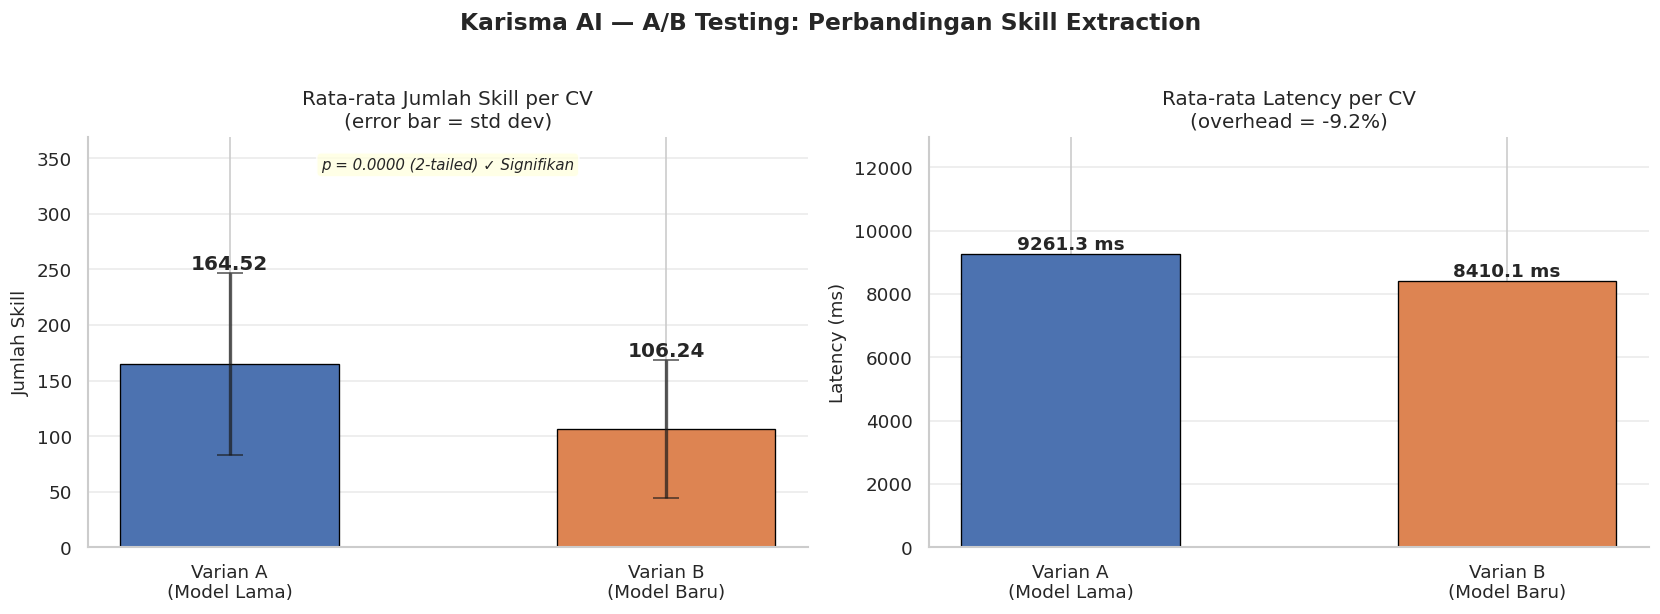

Plot disimpan: ab_test_barchart.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Karisma AI — A/B Testing: Perbandingan Skill Extraction',
    fontsize=14, fontweight='bold', y=1.02
)

ax1 = axes[0]
variants = ['Varian A\n(Model Lama)', 'Varian B\n(Model Baru)']
means    = [mean_a, mean_b]
errors   = [std_a, std_b]
colors   = ['#4C72B0', '#DD8452']

bars = ax1.bar(
    variants, means,
    yerr=errors,
    capsize=8,
    color=colors,
    edgecolor='black',
    linewidth=0.8,
    width=0.5,
    error_kw={'elinewidth': 2, 'alpha': 0.7}
)

for bar, mean_val, std_val in zip(bars, means, errors):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + std_val + 0.2,
        f'{mean_val:.2f}',
        ha='center', va='bottom',
        fontsize=12, fontweight='bold'
    )

if mean_b > mean_a:
    ax1.annotate(
        f'+{improvement_pct:.1f}%',
        xy=(1, mean_b), xytext=(0.5, (mean_a + mean_b) / 2 + std_b),
        fontsize=11, color='green', fontweight='bold',
        ha='center',
        arrowprops=dict(arrowstyle='->', color='green', lw=1.5)
    )

ax1.set_title('Rata-rata Jumlah Skill per CV\n(error bar = std dev)', fontsize=12)
ax1.set_ylabel('Jumlah Skill', fontsize=11)
ax1.set_ylim(0, max(means) + max(errors) * 2.5)

# two-tailed
sig_text = f'p = {p_value:.4f} (2-tailed) {"✓ Signifikan" if is_significant else "✗ Tidak Signifikan"}'
ax1.text(0.5, 0.95, sig_text,
         transform=ax1.transAxes, ha='center', va='top',
         fontsize=9, style='italic',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

ax1.grid(axis='y', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
latencies = [avg_latency_a, avg_latency_b]

bars2 = ax2.bar(
    variants, latencies,
    color=colors,
    edgecolor='black',
    linewidth=0.8,
    width=0.5,
)

for bar, lat_val in zip(bars2, latencies):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{lat_val:.1f} ms',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold'
    )

ax2.set_title(f'Rata-rata Latency per CV\n(overhead = {latency_overhead_pct:+.1f}%)', fontsize=12)
ax2.set_ylabel('Latency (ms)', fontsize=11)
ax2.set_ylim(0, max(latencies) * 1.4)
ax2.grid(axis='y', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('ab_test_barchart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan: ab_test_barchart.png')


---
## 📦 Cell 9 — Visualisasi 2: Box Plot Distribusi Skill


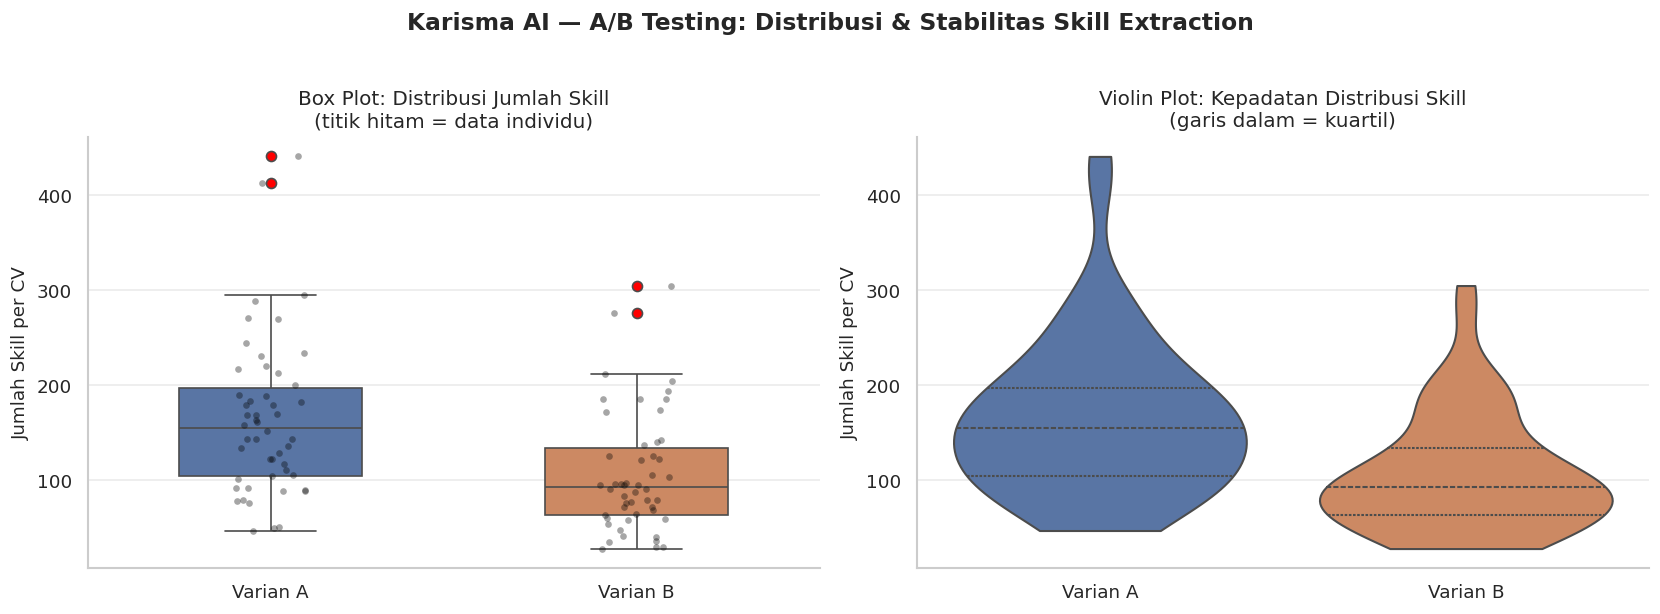

Plot disimpan: ab_test_boxplot.png


In [35]:
df_long = pd.DataFrame({
    'Varian'      : ['Varian A'] * len(skill_counts_a) + ['Varian B'] * len(skill_counts_b),
    'Jumlah Skill': list(skill_counts_a) + list(skill_counts_b)
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    'Karisma AI — A/B Testing: Distribusi & Stabilitas Skill Extraction',
    fontsize=14, fontweight='bold', y =1.02
)

palette = {'Varian A': '#4C72B0', 'Varian B': '#DD8452'}

ax1 = axes[0]
sns.boxplot(
    data=df_long, x='Varian', y='Jumlah Skill',
    palette=palette, width=0.5,
    flierprops={'marker': 'o', 'markerfacecolor': 'red', 'markersize': 6},
    ax=ax1
)
sns.stripplot(
    data=df_long, x='Varian', y='Jumlah Skill',
    color='black', alpha=0.35, size=4, jitter=True, ax=ax1
)
ax1.set_title('Box Plot: Distribusi Jumlah Skill\n(titik hitam = data individu)', fontsize=12)
ax1.set_ylabel('Jumlah Skill per CV', fontsize=11)
ax1.set_xlabel('')
ax1.grid(axis='y', alpha=0.4)
ax1.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
sns.violinplot(
    data=df_long, x='Varian', y='Jumlah Skill',
    palette=palette, inner='quartile',
    cut=0,
    ax=ax2
)
ax2.set_title('Violin Plot: Kepadatan Distribusi Skill\n(garis dalam = kuartil)', fontsize=12)
ax2.set_ylabel('Jumlah Skill per CV', fontsize=11)
ax2.set_xlabel('')
ax2.grid(axis='y', alpha=0.4)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('ab_test_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot disimpan: ab_test_boxplot.png')


---
## 📈 Cell 10 — Visualisasi 3: Skill Diff per CV & Trend


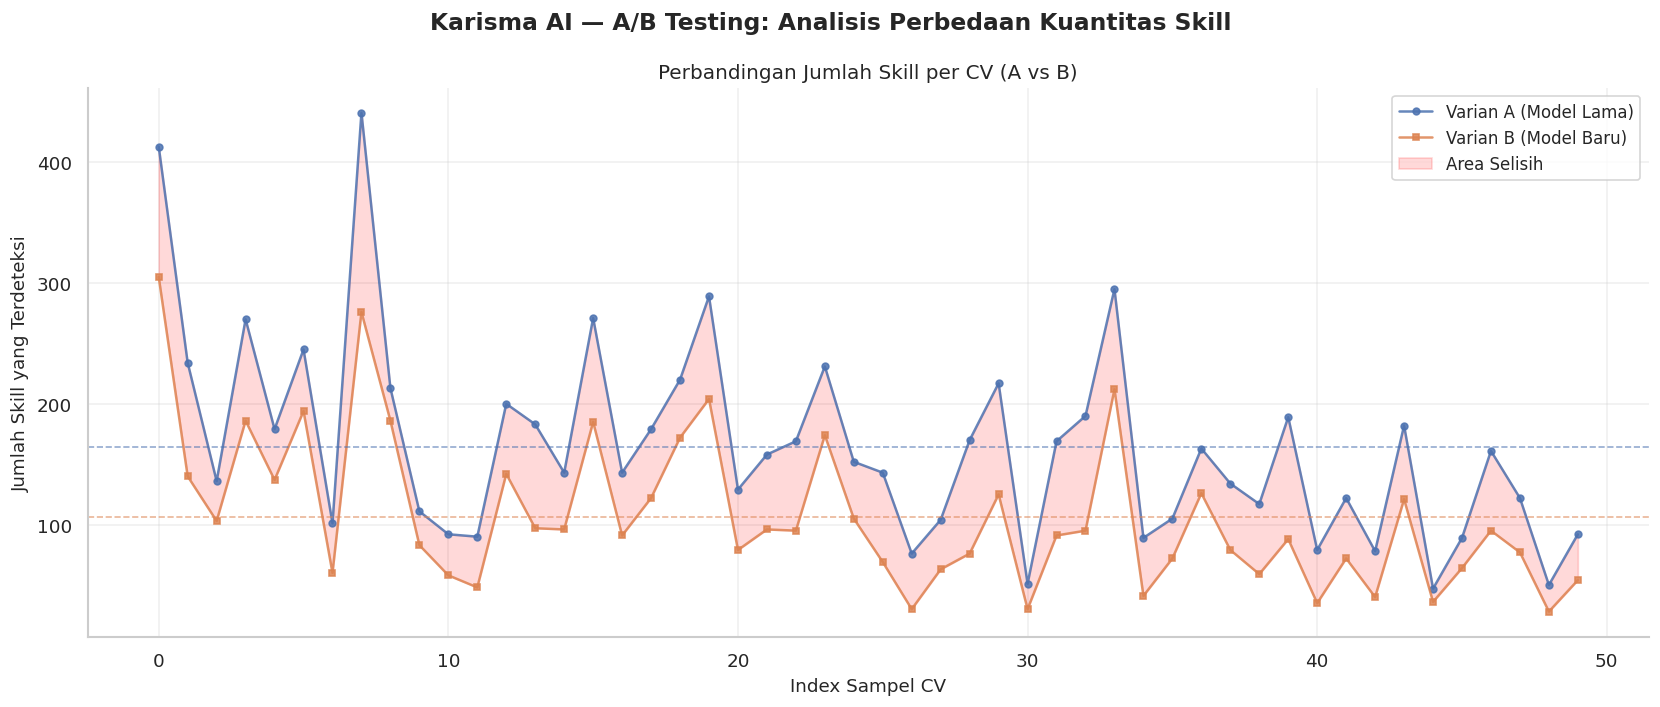

✅ Plot perbandingan jumlah skill berhasil dibuat dan disimpan ke ab_test_diff_per_cv.png


In [36]:
fig, ax1 = plt.subplots(figsize=(14, 6))
fig.suptitle(
    'Karisma AI — A/B Testing: Analisis Perbedaan Kuantitas Skill',
    fontsize=14, fontweight='bold'
)

x_idx = range(len(df_results))

ax1.plot(x_idx, df_results['skill_count_a'],
         label='Varian A (Model Lama)', color='#4C72B0',
         marker='o', markersize=4, linewidth=1.5, alpha=0.85)

ax1.plot(x_idx, df_results['skill_count_b'],
         label='Varian B (Model Baru)', color='#DD8452',
         marker='s', markersize=4, linewidth=1.5, alpha=0.85)

ax1.fill_between(
    x_idx,
    df_results['skill_count_a'],
    df_results['skill_count_b'],
    alpha=0.15,
    color='green' if mean_b > mean_a else 'red',
    label='Area Selisih'
)

ax1.axhline(mean_a, color='#4C72B0', linestyle='--', linewidth=1, alpha=0.6)
ax1.axhline(mean_b, color='#DD8452', linestyle='--', linewidth=1, alpha=0.6)

ax1.set_title('Perbandingan Jumlah Skill per CV (A vs B)', fontsize=12)
ax1.set_ylabel('Jumlah Skill yang Terdeteksi', fontsize=11)
ax1.set_xlabel('Index Sampel CV', fontsize=11)
ax1.legend(fontsize=10)
ax1.grid(alpha=0.3)
ax1.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('ab_test_diff_per_cv.png', dpi=150, bbox_inches='tight')
plt.show()

print('✅ Plot perbandingan jumlah skill berhasil dibuat dan disimpan ke ab_test_diff_per_cv.png')

---
## 🏆 Cell 11 — Tabel Ringkasan: Top 5 CV dengan Perbedaan Ekstraksi Terbesar


In [37]:
df_top5 = (
    df_results
    .assign(abs_diff=df_results['skill_diff'].abs())
    .nlargest(5, 'abs_diff')
    .reset_index(drop=True)
)

print('=' * 75)
print('  TOP 5 CV DENGAN PERBEDAAN SKILL EXTRACTION PALING SIGNIFIKAN')
print('=' * 75)
print()

for i, row in df_top5.iterrows():
    print(f'  #{i+1}. {row["file_name"]}')
    print(f'       Skill A ({row["skill_count_a"]:2d}) : {row["extracted_skills_a"][:5]}...')
    print(f'       Skill B ({row["skill_count_b"]:2d}) : {row["extracted_skills_b"][:5]}...')
    sign   = '+' if row['skill_diff'] > 0 else ''
    winner = 'Varian B lebih banyak' if row['skill_diff'] > 0 else 'Varian A lebih banyak' if row['skill_diff'] < 0 else '↔ Sama'
    print(f'       Selisih (B-A): {sign}{row["skill_diff"]} skill  →  {winner}')
    print(f'       Latency A/B : {row["latency_a_ms"]} ms / {row["latency_b_ms"]} ms')
    print()

print('=' * 75)

display_cols = ['file_name', 'skill_count_a', 'skill_count_b', 'skill_diff', 'latency_a_ms', 'latency_b_ms']
display_rename = {
    'file_name'    : 'File CV',
    'skill_count_a': 'Skill A',
    'skill_count_b': 'Skill B',
    'skill_diff'   : 'Selisih (B-A)',
    'latency_a_ms' : 'Latency A (ms)',
    'latency_b_ms' : 'Latency B (ms)'
}

df_display = df_top5[display_cols].rename(columns=display_rename)
print()
print('Tabel Ringkasan Top 5 CV:')
print(df_display.to_string(index=False))


  TOP 5 CV DENGAN PERBEDAAN SKILL EXTRACTION PALING SIGNIFIKAN

  #1. 19796840.pdf
       Skill A (441) : ['information technology auditor', 'peoplesoft hcm', 'peoplesoft financials', 'peopletools', 'sql developer']...
       Skill B (276) : ['information technology auditor', 'peopletools 8.51/', 'sql developer', 'ms office', 'visio']...
       Selisih (B-A): -165 skill  →  Varian A lebih banyak
       Latency A/B : 18580.92 ms / 17172.05 ms

  #2. 18067556.pdf
       Skill A (413) : ['master data manager', '01/2019', 'state', '100+ supply chain-related', 'master data attributes']...
       Skill B (305) : ['master data manager', 'master data attributes', 'ownership established', 'definitions', 'impact documentation']...
       Selisih (B-A): -108 skill  →  Varian A lebih banyak
       Latency A/B : 39100.99 ms / 22272.8 ms

  #3. 29815762.pdf
       Skill A (189) : ['sales associte', 'motivated to maintain', 'customer satisfaction', 'company success', 'addressing customer']...
       

---
## 📋 Cell 12 — Simpan Hasil & Laporan Final


In [38]:
import os
OUTPUT_DIR = os.path.join(BASE_PATH, 'output_ab_testing')

# Buat folder jika belum ada
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f'Folder dibuat: {OUTPUT_DIR}')

csv_filename = os.path.join(OUTPUT_DIR, 'ab_testing_results_detail.csv')
output_cols = [
    'file_name', 'skill_count_a', 'skill_count_b',
    'skill_diff', 'latency_a_ms', 'latency_b_ms',
    'extracted_skills_a', 'extracted_skills_b'
]
df_results[output_cols].to_csv(csv_filename, index=False)
print(f'Hasil detail disimpan: {csv_filename}')

# 4. Simpan Ringkasan Statistik ke JSON
json_filename = os.path.join(OUTPUT_DIR, 'ab_testing_summary.json')
with open(json_filename, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print(f'Ringkasan statistik disimpan: {json_filename}')

✅ Hasil detail disimpan: /content/drive/MyDrive/KARISMA/output_ab_testing/ab_testing_results_detail.csv
✅ Ringkasan statistik disimpan: /content/drive/MyDrive/KARISMA/output_ab_testing/ab_testing_summary.json
